# Runtime Benchmark for Fast Manhattan Silhouette

This notebook produces thesis-ready runtime plots for RQ1--RQ3 and the special
1D fast-path comparison.


In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.ticker import StrMethodFormatter
from matplotlib.axes import Axes
import numpy as np
from _conf import (
    SIMPLIFIED_RESULTS,
    PUBLIC_DATA,
    PLOT_DOC_FULL_WIDTH,
)
from _utils.schema import ResultKey

FIGURE_DIR = PUBLIC_DATA / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

strategy_mapping: dict[str, str] = {
    "fast_general_score": "Fast manhattan silhouette",
    "fast_by_cluster_score": "Cluster-first FMS",
    "fast_by_axis_score": "Dimension-first FMS",
    "sklearn_manhattan": "Standard implementation",
}


def save_figure(name: str, fig: Figure):
    path = FIGURE_DIR / name
    fig.savefig(path.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(path.with_suffix(".png"), bbox_inches="tight")


# sns.set_theme(style="whitegrid", context="paper")
sns.set_theme(style="darkgrid", context="paper")
print(plt.rcParams["axes.labelsize"])
print(plt.rcParams["figure.labelsize"])
plt.rcParams["figure.dpi"] = 140
plt.rcParams.update(
    {
        "axes.labelsize": 10,
        "figure.labelsize": 10,
    }
)

rq_col = ResultKey.RQ.value
n_col = ResultKey.N.value
k_col = ResultKey.K.value
dim_col = ResultKey.DIM.value
asw_col = ResultKey.ASW.value
kind_col = ResultKey.KIND.value
strategy_col = "strategy"
runtime_col = "runtime"

9.600000000000001
10.0


## Quick look at the data

Just as a quick reference to remember which columns are available. Double check
for stupid mistakes.


In [3]:
results = pd.read_json(SIMPLIFIED_RESULTS)
results.drop(columns=["instance_name"], inplace=True)
results = results[results[strategy_col] != "fast_auto_score"]
results.replace(
    {strategy_col: strategy_mapping},
    inplace=True,
)

results.sort_values(
    [rq_col, n_col, k_col, dim_col],
    inplace=True,
)
results

,rq,n,k,dim,kind,runtime,timestamp,strategy,asw
21,rq1_n_scaling,200000,5,1,blobs,92.462149,2026-05-05 02:34:23.641,Standard implementation,0.398298
89,rq1_n_scaling,200000,5,1,uniform,94.271756,2026-05-07 02:36:38.343,Standard implementation,-0.322895
292,rq1_n_scaling,200000,5,1,blobs,0.025592,2026-05-08 17:17:35.456,Cluster-first FMS,0.398298
293,rq1_n_scaling,200000,5,1,blobs,0.032171,2026-05-08 17:17:35.488,Dimension-first FMS,0.398298
251,rq1_n_scaling,200000,5,1,uniform,0.030807,2026-05-08 17:20:27.841,Cluster-first FMS,-0.322895
...,...,...,...,...,...,...,...,...,...
437,rq3_D_scaling,100000,5,400,uniform,3.346014,2026-05-08 17:39:57.360,Dimension-first FMS,-0.006900
438,rq3_D_scaling,100000,5,400,uniform,2177.455336,2026-05-08 17:40:00.811,Standard implementation,-0.006900
478,rq3_D_scaling,100000,5,400,blobs,3.597935,2026-05-08 17:40:24.022,Cluster-first FMS,0.830214
479,rq3_D_scaling,100000,5,400,blobs,3.267070,2026-05-08 17:40:27.638,Dimension-first FMS,0.830214


## Check if ASW same


In [18]:
# def almost_same_asw(s: pd.api.typing.DataFrameGroupBy, *, rtol=1e-5, atol=1e-8):
#     x = s.to_numpy()
#     return np.allclose(x, x[0], rtol=rtol, atol=atol)
grouped = results.groupby([rq_col, n_col, k_col, dim_col, kind_col])

summary = (
    grouped[asw_col]
    .agg(
        min="min",
        max="max",
        count="count",
    )
    .assign(asw_almost_same=lambda df: (df["max"] - df["min"]) <= 1e-80)
    .reset_index()
)
bad = summary[~summary["asw_almost_same"]]

display(bad)

,rq,n,k,dim,kind,min,max,count,asw_almost_same


## RQ1: How does runtime scale with n?


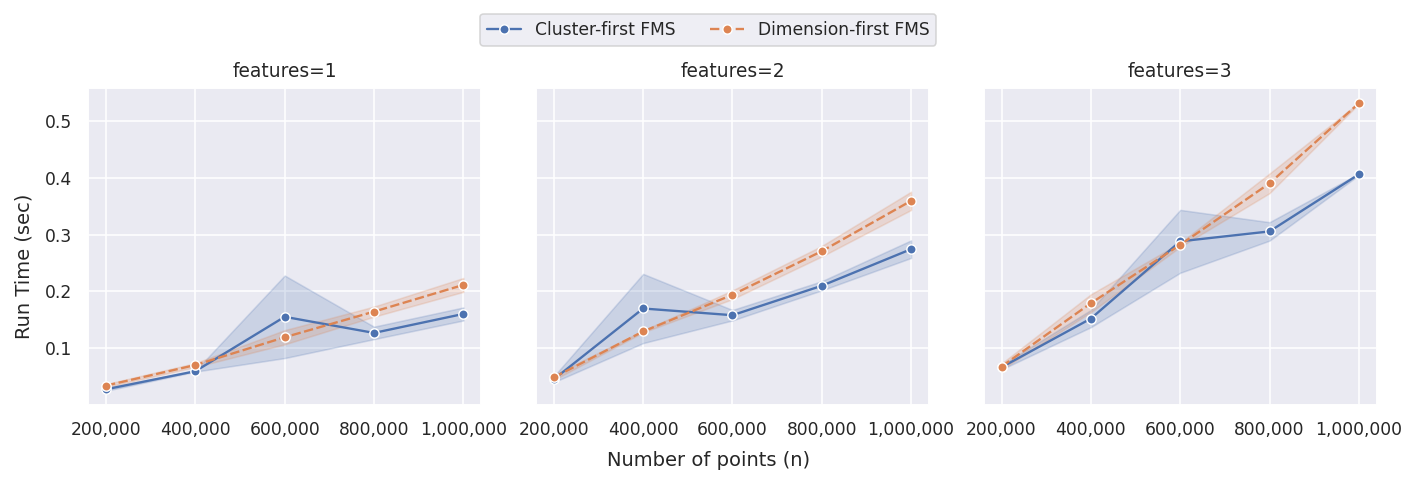

In [12]:
rq1_data = results[results[rq_col].str.contains("rq1")]
dimensions = np.sort(rq1_data[dim_col].unique())
# rq1_data = rq1_data[~rq1_data[strategy_col].isin(["Dimension-first FMS"])]
rq1_data = rq1_data[
    ~rq1_data[strategy_col].isin([strategy_mapping["sklearn_manhattan"]])
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(dimensions),
    sharex=True,
    sharey=True,
    figsize=(PLOT_DOC_FULL_WIDTH, 3),
    layout="constrained",
)
axes: list[Axes]

for ax, dim in zip(axes, dimensions, strict=True):
    part = rq1_data[rq1_data[dim_col] == dim]
    sns.lineplot(
        data=part,
        x=n_col,
        y=runtime_col,
        hue=strategy_col,
        style=strategy_col,
        dashes=True,
        estimator="mean",
        errorbar=("ci", 95),
        marker="o",
        ax=ax,
    )
    ax.set_title(f"features={dim}")

    # Remove per axis labels, keep one shared label
    ax.set_xlabel("")
    ax.set_ylabel("")
    # ax.ticklabel_format(axis="x", style="plain")
    ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

    legend = ax.get_legend()
    if legend is not None:
        legend.remove()


# Shared labels
fig.supxlabel("Number of points (n)")
fig.supylabel("Run Time (sec)")

# keep one legend for whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    # title="Algorithm",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=len(labels),
    # frameon=False,
    # fontsize=8,
    # title_fontsize=8,
)
# fig.suptitle("RQ1: Runtime scaling in number of points")

save_figure("rq1_runtime_n_scale", fig)
# unterschiedlich breite punktung

## RQ2: How does runtime scale with K?


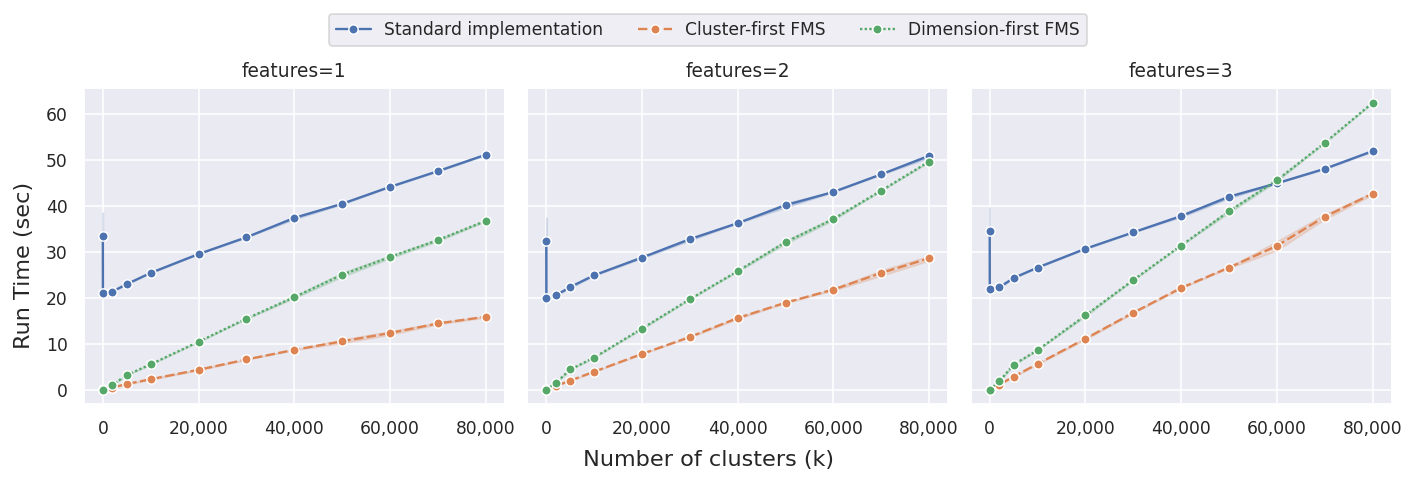

In [8]:
# Breite von Tesxt und Font size anpassen

rq2_data = results[results[rq_col].str.contains("rq2")]
rq2_data = rq2_data[
    rq2_data[k_col].isin(
        [
            2,
            16,
            2000,
            5000,
            10_000,
            20_000,
            30_000,
            40_000,
            50_000,
            60_000,
            70_000,
            80_000,
        ]
    )
]

# rq2_data = rq2_data[~rq2_data[strategy_col].isin(["Standard implementation"])]
dimensions = np.sort(rq2_data[dim_col].unique())

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(dimensions),
    sharex=True,
    sharey=True,
    figsize=(PLOT_DOC_FULL_WIDTH, 3),
    layout="constrained",
)
axes: list[Axes]

for ax, dim in zip(axes, dimensions, strict=True):
    part = rq2_data[rq2_data[dim_col] == dim]
    sns.lineplot(
        data=part,
        x=k_col,
        y=runtime_col,
        hue=strategy_col,
        style=strategy_col,
        dashes=True,
        estimator="mean",
        errorbar=("ci", 95),
        marker="o",
        ax=ax,
    )
    ax.set_title(f"features={dim}")

    # Remove per axis labels, keep one shared label
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xscale("linear")
    ax.set_yscale("linear")

    # Print pretty ticks: instead of 1e6 -> 1,000,000
    ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

# Shared labels
fig.supxlabel("Number of clusters (k)")
fig.supylabel("Run Time (sec)")

# keep one legend for whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    # title="Algorithm",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=len(labels),
    # frameon=False,
    # fontsize=8,
    # title_fontsize=8,
)
# fig.suptitle("RQ1: Runtime scaling in number of points")

save_figure("rq2_runtime_k_scale", fig)

## RQ3: How does runtime scale with dimensions d?


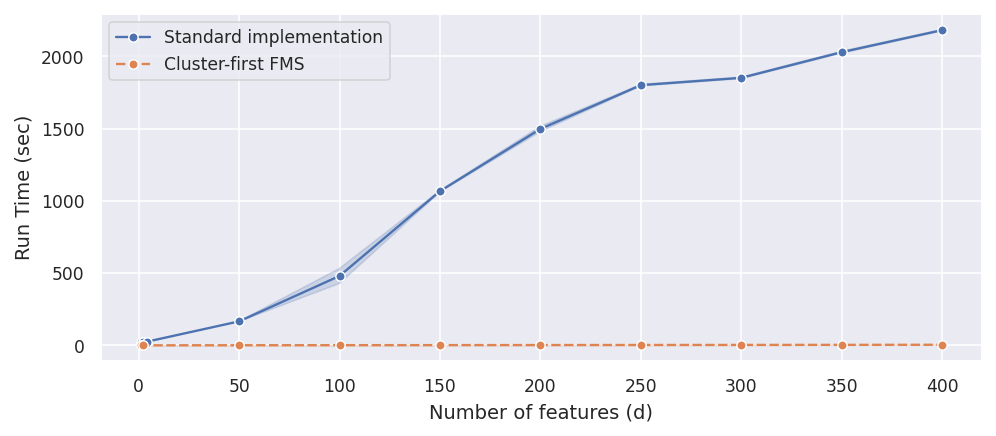

In [17]:
# Breite von Tesxt und Font size anpassen

rq3_data = results[results[rq_col].str.contains("rq3")]
# print(rq3_data[rq3_data[dim_col] < 50][dim_col])
rq3_data = rq3_data[~rq3_data[dim_col].isin([8, 16, 32, 64, 128, 256])]
# rq3_data = rq3_data[~rq3_data[strategy_col].isin(["Standard implementation"])]
rq3_data = rq3_data[~rq3_data[strategy_col].isin(["Dimension-first FMS"])]
fig, ax = plt.subplots(
    figsize=(7, 3),
    layout="constrained",
)

sns.lineplot(
    data=rq3_data,
    x=dim_col,
    y=runtime_col,
    hue=strategy_col,
    style=strategy_col,
    dashes=True,
    estimator="mean",
    errorbar=("ci", 95),
    marker="o",
    ax=ax,
)
# ax.set_title("RQ3: Runtime scaling in dimension")
ax.set_xlabel("Number of features (d)")
ax.set_ylabel("Run Time (sec)")
ax.set_xscale("linear")
ax.set_yscale("linear")
ax.legend(title="")
# Print pretty ticks: instead of 1e6 -> 1,000,000
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

save_figure("rq3_runtime_d_scale", fig)